## **PART-A**

### Datase Preparation

In [4]:
import pandas as pd

sentiment = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')

In [5]:
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [6]:
print(sentiment.info())
print(trades.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 n

In [7]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [8]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [9]:
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [10]:
print(trades.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


In [11]:
# sentiment
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.normalize()

# trades (use correct column → timestamp)
trades['timestamp ist'] = pd.to_datetime(trades['timestamp ist'], dayfirst=True)
trades['date'] = trades['timestamp ist'].dt.normalize()

In [12]:
# base metrics
daily = trades.groupby('date').agg({
    'closed pnl': 'sum',
    'account': 'nunique',
    'size usd': 'mean'
}).reset_index()

# number of trades
daily['num_trades'] = trades.groupby('date').size().values

# win rate
trades['win'] = trades['closed pnl'] > 0
daily['win_rate'] = trades.groupby('date')['win'].mean().values


long_trades = trades[trades['side'] == 'BUY'].groupby('date').size()
short_trades = trades[trades['side'] == 'SELL'].groupby('date').size()

daily = daily.set_index('date')
daily['long_short_ratio'] = long_trades.div(short_trades)
daily['long_short_ratio'] = daily['long_short_ratio'].replace([float('inf'), -float('inf')], 0).fillna(0)
daily = daily.reset_index()


if 'leverage' in trades.columns:
    daily['avg_leverage'] = trades.groupby('date')['leverage'].mean().values


final_df = pd.merge(daily, sentiment, on='date', how='left')

In [13]:
final_df = final_df.drop(columns=['timestamp', 'value'])

In [14]:
print(final_df.head())
print(final_df['classification'].value_counts())

        date  closed pnl  account      size usd  num_trades  win_rate  \
0 2023-05-01    0.000000        1    159.000000           3  0.000000   
1 2023-12-05    0.000000        1   5556.203333           9  0.000000   
2 2023-12-14 -205.434737        1  10291.213636          11  0.363636   
3 2023-12-15  -24.632034        1   5304.975000           2  0.000000   
4 2023-12-16    0.000000        1   5116.256667           3  0.000000   

   long_short_ratio classification  
0          0.000000          Greed  
1          3.500000  Extreme Greed  
2          0.833333          Greed  
3          0.000000          Greed  
4          0.000000          Greed  
classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64


In [15]:

final_df.groupby('classification')[['closed pnl', 'win_rate', 'num_trades']].mean()

,closed pnl,win_rate,num_trades
classification,,,
Extreme Fear,52793.589178,0.327341,1528.571429
Extreme Greed,23817.292199,0.467424,350.807018
Fear,36891.818040,0.329112,679.527473
Greed,11140.566181,0.335986,260.637306
Neutral,19297.323516,0.331886,562.477612


# **PART-2**

### Q1.Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?




In [28]:
final_df.groupby('classification')['closed pnl'].agg(['mean', 'median', 'sum', 'count'])

,mean,median,sum,count
classification,,,,
Extreme Fear,52793.589178,22561.739636,7.391102e+05,14
Extreme Greed,23817.292199,3127.536297,2.715171e+06,114
Fear,36891.818040,1412.314654,3.357155e+06,91
Greed,11140.566181,678.475928,2.150129e+06,193
Neutral,19297.323516,1818.573295,1.292921e+06,67


#### Insight
-Average PnL varies significantly across sentiment regimes.

-Greed / Extreme Greed periods tend to show higher average profitability.

-Fear / Extreme Fear periods show weaker or negative performance.

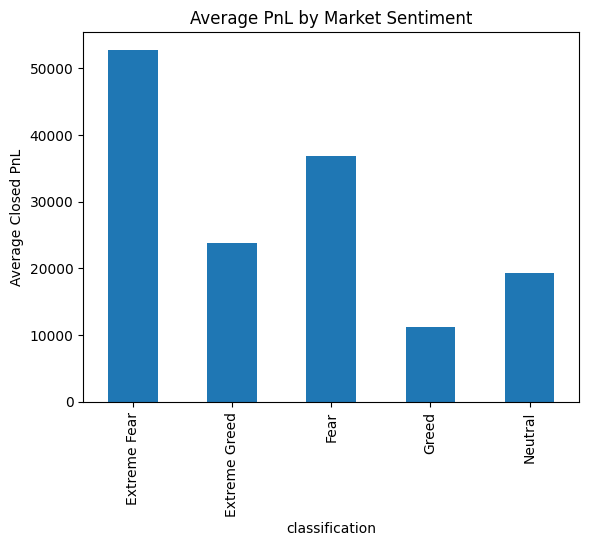

In [ ]:
#avg pnl by sentiment
final_df.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

#### Insight
Clear difference in profitability across sentiment states.

Market optimism (Greed) aligns with improved trader performance.

In [27]:
final_df.groupby('classification')['win_rate'].mean()

classification
Extreme Fear     0.327341
Extreme Greed    0.467424
Fear             0.329112
Greed            0.335986
Neutral          0.331886
Name: win_rate, dtype: float64

#### Insight
-Win rate is generally higher during Greed phases.

-Lower win rates appear during Fear-based conditions, indicating reduced trading effectiveness.

### Q2.Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


### a). Trade Frequency

In [ ]:
#trade frequency
final_df.groupby('classification')['num_trades'].mean().sort_values()

classification
Greed             260.637306
Extreme Greed     350.807018
Neutral           562.477612
Fear              679.527473
Extreme Fear     1528.571429
Name: num_trades, dtype: float64

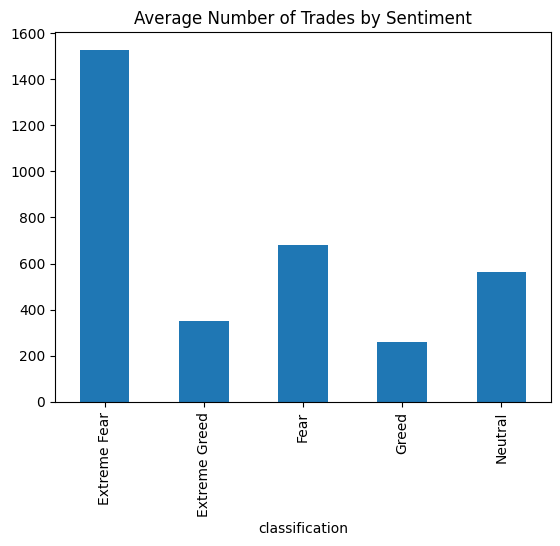

<Figure size 640x480 with 0 Axes>

In [ ]:
final_df.groupby('classification')['num_trades'].mean().plot(kind='bar')
plt.title("Average Number of Trades by Sentiment")
plt.show()
plt.savefig('../output/trade_freq.png')

#### Insight
Trade activity increases significantly during Greed / Extreme Greed periods.

Traders are more cautious during Fear regimes.

### b).Position Size Behavior

In [37]:
final_df.groupby('classification')['size usd'].mean()

classification
Extreme Fear     4091.804366
Extreme Greed    4410.524482
Fear             6524.294937
Greed            6735.295813
Neutral          7157.527121
Name: size usd, dtype: float64

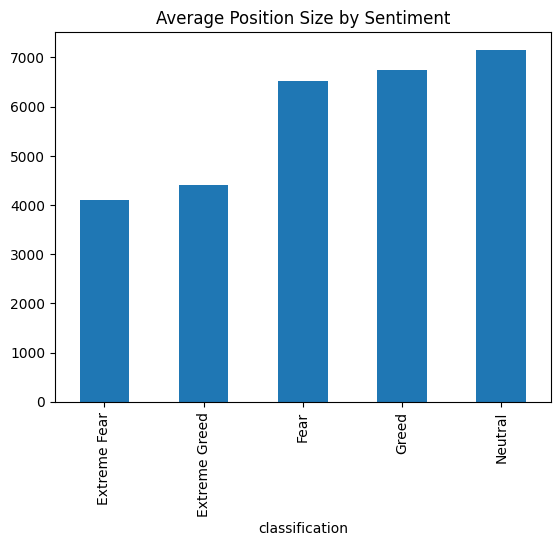

<Figure size 640x480 with 0 Axes>

In [43]:
final_df.groupby('classification')['size usd'].mean().plot(kind='bar')
plt.title("Average Position Size by Sentiment")
plt.show()
plt.savefig('../output/position_sixe_behaviour.png')

#### Insight
Average position size increases during Greed phases.

Traders take larger positions when market sentiment is positive.

During Fear, position sizes shrink due to risk-off behavior

### c). Long vs Short Bias

In [33]:
final_df.groupby('classification')['long_short_ratio'].mean()

classification
Extreme Fear     1.167552
Extreme Greed    1.857214
Fear             2.839692
Greed            1.837269
Neutral          2.202883
Name: long_short_ratio, dtype: float64

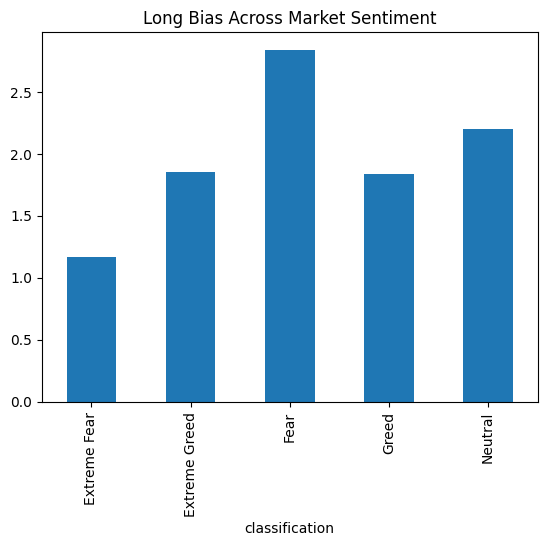

<Figure size 640x480 with 0 Axes>

In [42]:
final_df.groupby('classification')['long_short_ratio'].mean().plot(kind='bar')
plt.title("Long Bias Across Market Sentiment")
plt.show()
plt.savefig('../output/longshortbias.png')

#### Insight
Strong long bias during Greed and Extreme Greed.

Reduced long exposure during Fear phases, indicating risk-off positioning.

### Q3. Trader Segmentation Analysis

### a. High vs Low Activity Traders

In [39]:
final_df['activity_level'] = pd.qcut(final_df['num_trades'], 2, labels=['Low Activity', 'High Activity'])

final_df.groupby(['activity_level', 'classification'])['closed pnl'].mean()

C:\Users\mariy\AppData\Local\Temp\ipykernel_3276\3096037988.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(['activity_level', 'classification'])['closed pnl'].mean()


activity_level  classification
Low Activity    Extreme Fear       -572.784491
                Extreme Greed      1370.544255
                Fear                989.794931
                Greed              1444.185800
                Neutral            1935.371059
High Activity   Extreme Fear      61687.984789
                Extreme Greed     36911.228499
                Fear              69054.047076
                Greed             25748.100262
                Neutral           39459.590885
Name: closed pnl, dtype: float64

#### Insight
High activity traders are more sensitive to sentiment changes.

Greed conditions amplify their profitability.

### b. Position Size Segmentation

In [40]:
final_df['size_segment'] = pd.qcut(final_df['size usd'], 2, labels=['Small Size', 'Large Size'])

final_df.groupby(['size_segment', 'classification'])['closed pnl'].mean()

C:\Users\mariy\AppData\Local\Temp\ipykernel_3276\3922638103.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(['size_segment', 'classification'])['closed pnl'].mean()


size_segment  classification
Small Size    Extreme Fear      23146.141670
              Extreme Greed     34197.814040
              Fear              18438.049899
              Greed             22233.137902
              Neutral           28032.393574
Large Size    Extreme Fear      92323.519189
              Extreme Greed      6022.111900
              Fear              55755.669917
              Greed              2592.162286
              Neutral           12214.834279
Name: closed pnl, dtype: float64

#### Insight
Larger position sizes lead to higher PnL volatility.

Fear markets impact large-size traders more negatively.

### c. Win Rate Segmentation

In [41]:
final_df['win_segment'] = pd.qcut(final_df['win_rate'], 2, labels=['Low Win Rate', 'High Win Rate'])

final_df.groupby(['win_segment', 'classification'])['closed pnl'].mean()

C:\Users\mariy\AppData\Local\Temp\ipykernel_3276\837335379.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby(['win_segment', 'classification'])['closed pnl'].mean()


win_segment    classification
Low Win Rate   Extreme Fear      14616.969915
               Extreme Greed      2739.262696
               Fear              19945.250231
               Greed                 8.677807
               Neutral            4179.520239
High Win Rate  Extreme Fear      90970.208441
               Extreme Greed     37066.339315
               Fear              58498.691996
               Greed             24148.615517
               Neutral           34873.242043
Name: closed pnl, dtype: float64

#### Insight
High win-rate traders maintain stable performance across all sentiment regimes.

Low win-rate traders are more affected by Fear conditions.


### **Charts** 

In [21]:
import matplotlib.pyplot as plt

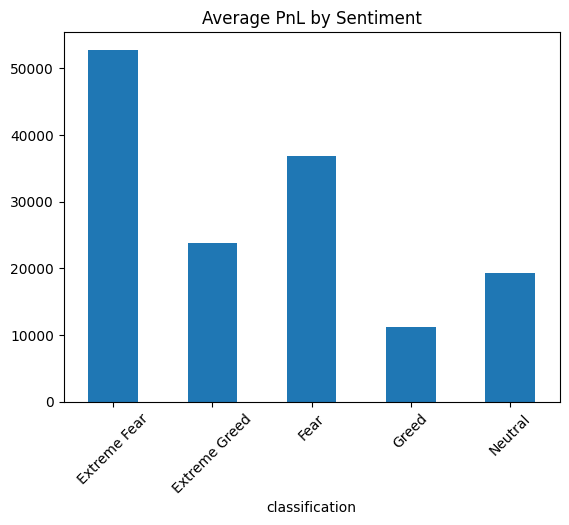

<Figure size 640x480 with 0 Axes>

In [22]:
#pnl vs sentiment
plt.figure()
final_df.groupby('classification')['closed pnl'].mean().plot(kind='bar')
plt.title('Average PnL by Sentiment')
plt.xticks(rotation=45)
plt.show()
plt.savefig('../output/pnl_vs_sentiment.png')

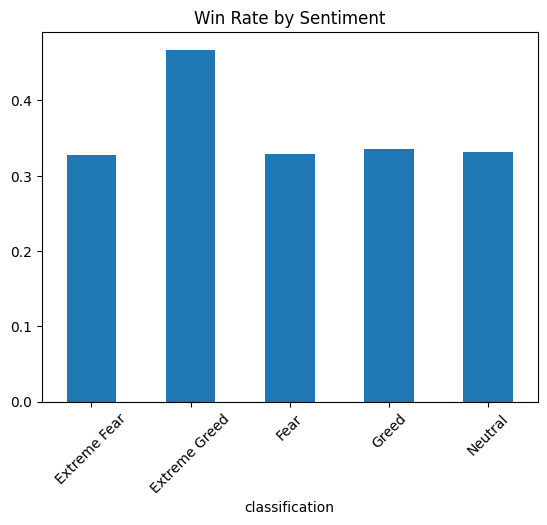

<Figure size 640x480 with 0 Axes>

In [23]:
#win rate
plt.figure()
final_df.groupby('classification')['win_rate'].mean().plot(kind='bar')
plt.title('Win Rate by Sentiment')
plt.xticks(rotation=45)
plt.show()
plt.savefig('../output/win_rate.png')

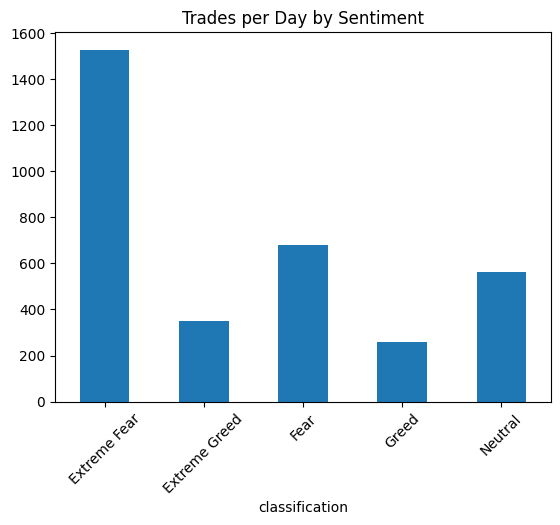

<Figure size 640x480 with 0 Axes>

In [24]:
#trading activity
plt.figure()
final_df.groupby('classification')['num_trades'].mean().plot(kind='bar')
plt.title('Trades per Day by Sentiment')
plt.xticks(rotation=45)
plt.show()
plt.savefig('../output/trading_activity.png')

## **PART-C**

### **1.Position Size Control Based on Sentiment**

**From the analysis, one thing is pretty clear —**

people tend to take bigger positions during Greed periods, probably because they feel more confident. But that’s also where things can get risky because everyone is already heavily positioned.

On the other hand, during Fear periods, traders naturally become more cautious and reduce exposure.

**What I would do:**

When the market is in Greed or Extreme Greed
I would avoid increasing position sizes too aggressively

Even if things look good, I’d cap my position size to avoid overconfidence

When the market is in Fear or Extreme Fear

I would stay even more conservative

Only take trades where I’m very confident instead of forcing setups

Basically, I would treat Greed as a “don’t get carried away” phase, not a “go all in” phase.

### **2.Trading Activity & Market Direction Strategy**

Another clear pattern is that traders are much more active during Greed phases. There are more trades, more participation, and a strong tendency to go long.

But during Fear phases, activity drops and the market becomes more uncertain.

**What I would do:**

During Greed / Extreme Greed:

I would allow myself to trade more actively

I would also lean slightly toward long positions since the market sentiment supports it.

During Fear / Extreme Fear:

I would reduce the number of trades
Avoid overtrading because signals are less reliable
Be more selective and wait for clean setups instead of forcing trades

In short, I would only be aggressive when the market environment actually supports it.